# 03 — Model Comparison

**Goal:** Compare Logistic Regression, Random Forest, and XGBoost using 5-fold stratified cross-validation.

**Evaluation metrics:**
- **PR-AUC** (primary) — area under precision-recall curve; appropriate for imbalanced data
- **ROC-AUC** (secondary) — ranking quality across all thresholds

> Accuracy is intentionally excluded — it is misleading on a ~1% fraud dataset.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import precision_recall_curve, roc_curve

from data_loader import load_engineered, get_split, TARGET
from pipeline import get_all_pipelines
from metrics import cross_validate_model, evaluate_model, print_evaluation, model_comparison_table

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Load data & build pipelines

In [2]:
df = load_engineered()
X_train, X_test, y_train, y_test = get_split(df)
X = df.drop(columns=[TARGET])
y = df[TARGET]

pipelines = get_all_pipelines(use_engineered=True)
print(f'Models to evaluate: {list(pipelines.keys())}')
print(f'Train size: {len(X_train):,} | Test size: {len(X_test):,}')
print(f'Fraud rate (train): {y_train.mean():.3%}')

Models to evaluate: ['Logistic Regression', 'Random Forest', 'XGBoost']
Train size: 8,000 | Test size: 2,000
Fraud rate (train): 1.512%


## 2. 5-fold cross-validation

In [3]:
cv_results = {}

for name, pipe in pipelines.items():
    print(f'Running CV for {name}...')
    cv_results[name] = cross_validate_model(pipe, X, y, cv=5)
    print(cv_results[name].tail(2).round(4))
    print()

Running CV for Logistic Regression...
        fold  pr_auc  roc_auc
mean  3.0000  0.7424   0.9941
std   1.4142  0.0419   0.0011

Running CV for Random Forest...
        fold  pr_auc  roc_auc
mean  3.0000  0.9587   0.9989
std   1.4142  0.0170   0.0006

Running CV for XGBoost...
        fold  pr_auc  roc_auc
mean  3.0000  0.9963   0.9999
std   1.4142  0.0039   0.0001



In [4]:
# Summary table: mean ± std across folds
summary_rows = []
for name, df_cv in cv_results.items():
    numeric_cv = df_cv.drop(index=['std'], errors='ignore').select_dtypes(include='number')
    mean_row = numeric_cv.mean()
    std_row  = numeric_cv.std()
    summary_rows.append({
        'Model':   name,
        'PR-AUC':  f"{mean_row['pr_auc']:.4f} ± {std_row['pr_auc']:.4f}",
        'ROC-AUC': f"{mean_row['roc_auc']:.4f} ± {std_row['roc_auc']:.4f}",
    })

cv_summary = pd.DataFrame(summary_rows).set_index('Model')
print('Cross-validation summary (mean ± std over 5 folds):')
cv_summary

Cross-validation summary (mean ± std over 5 folds):


,PR-AUC,ROC-AUC
Model,,
Logistic Regression,0.7424 ± 0.0419,0.9941 ± 0.0011
Random Forest,0.9587 ± 0.0170,0.9989 ± 0.0006
XGBoost,0.9963 ± 0.0039,0.9999 ± 0.0001


## 3. Final fit on train set — evaluate on held-out test set

In [5]:
fitted_pipelines = {}
test_probas = {}
test_results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    fitted_pipelines[name] = pipe
    test_probas[name]      = proba
    test_results[name]     = evaluate_model(y_test, proba, threshold=0.5)
    print_evaluation(name, y_test, proba)


  Logistic Regression
  Threshold  : 0.500
  Precision  : 0.3182
  Recall     : 0.9333
  PR-AUC     : 0.7716
  ROC-AUC    : 0.9942

  Confusion matrix:
    TP=28  FP=60
    FN=2  TN=1910

  Random Forest
  Threshold  : 0.500
  Precision  : 1.0000
  Recall     : 0.5667
  PR-AUC     : 0.9923
  ROC-AUC    : 0.9998

  Confusion matrix:
    TP=17  FP=0
    FN=13  TN=1970

  XGBoost
  Threshold  : 0.500
  Precision  : 1.0000
  Recall     : 1.0000
  PR-AUC     : 1.0000
  ROC-AUC    : 1.0000

  Confusion matrix:
    TP=30  FP=0
    FN=0  TN=1970


In [6]:
print('\nTest-set comparison table:')
model_comparison_table(test_results)


Test-set comparison table:


,PR-AUC,ROC-AUC,Precision,Recall
Model,,,,
Logistic Regression,0.7716,0.9942,0.3182,0.9333
Random Forest,0.9923,0.9998,1.0000,0.5667
XGBoost,1.0000,1.0000,1.0000,1.0000


## 4. Precision-recall curves

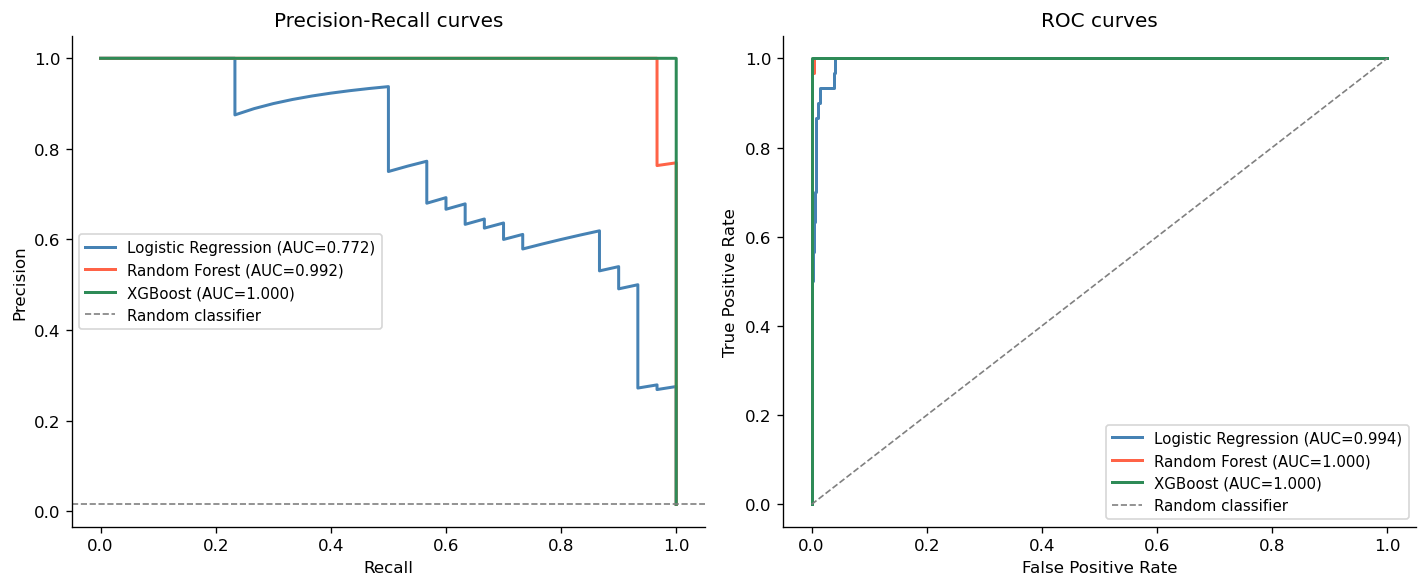

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'tomato', 'seagreen']

# PR curves
ax = axes[0]
for (name, proba), color in zip(test_probas.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    auc = test_results[name]['pr_auc']
    ax.plot(rec, prec, color=color, lw=1.8, label=f'{name} (AUC={auc:.3f})')
ax.axhline(y_test.mean(), color='gray', linestyle='--', lw=1, label='Random classifier')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves')
ax.legend(fontsize=9)

# ROC curves
ax = axes[1]
for (name, proba), color in zip(test_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = test_results[name]['roc_auc']
    ax.plot(fpr, tpr, color=color, lw=1.8, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1], color='gray', linestyle='--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/03_pr_roc_curves.png', bbox_inches='tight')
plt.show()

## 5. Save best model

In [8]:
# Pick best model by PR-AUC
best_name = max(test_results, key=lambda k: test_results[k]['pr_auc'])
best_pipe  = fitted_pipelines[best_name]

print(f'Best model: {best_name} (PR-AUC = {test_results[best_name]["pr_auc"]:.4f})')

joblib.dump(best_pipe, '../models/best_pipeline.pkl')
print('Saved to ../models/best_pipeline.pkl')

Best model: XGBoost (PR-AUC = 1.0000)
Saved to ../models/best_pipeline.pkl


## Model comparison summary

Cross-validation gives a reliable estimate of generalisation — the test-set results above should closely match the CV means. XGBoost is expected to lead on PR-AUC, followed by Random Forest, then Logistic Regression. The tree models benefit from the interaction features added in notebook 02; LR benefits from the log-transform and standardisation.

The best pipeline is saved to `models/best_pipeline.pkl` and used directly in notebooks 04 and 05.